# Fine-tune Gaze — Backbone từ `mobileone_s0_gaze.onnx`
**Chiến lược:** Cắt backbone từ ONNX gốc (frozen) → train FC heads mới với data CSV  
**Output:** `gaze_ft.onnx` cùng format, dùng thẳng trên Jetson Nano / TensorRT

**File cần có tại** `/content/drive/MyDrive/Colab Notebooks/PBL4/`:
- `mobileone_s0_gaze.onnx`
- `labels.csv`
- `dataset/` (tất cả ảnh flat, không chia subfolder)


In [1]:
import torch
assert torch.cuda.is_available(), "Runtime > Change runtime type > T4 GPU"
print(f"GPU: {torch.cuda.get_device_name(0)}")
!pip install -q onnx onnxruntime onnxsim


GPU: Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 75.1 MB/s eta 0:00:00


## 1. Mount Drive & kiểm tra file

In [3]:
from google.colab import drive
drive.mount("/content/drive")
import os, math, copy
import pandas as pd
import numpy as np
import onnx, onnxruntime as ort
import torch.nn as nn

BASE        = "/content/drive/MyDrive/Colab Notebooks/PBL4"
ONNX_ORIG   = os.path.join(BASE, "weights/mobileone_s0_gaze.onnx")
CSV_PATH    = os.path.join(BASE, "labels.csv")
IMG_DIR     = os.path.join(BASE, "dataset")
CKPT_DIR    = os.path.join(BASE, "checkpoints")
OUTPUT_ONNX = os.path.join(BASE, "checkpoints/gaze_ft_100ep.onnx")
os.makedirs(CKPT_DIR, exist_ok=True)

for f in [ONNX_ORIG, CSV_PATH]:
    sz = os.path.getsize(f)/1e6
    print(f"OK  {os.path.basename(f)}  ({sz:.1f} MB)")
assert os.path.isdir(IMG_DIR), f"Thiếu thư mục {IMG_DIR}"
imgs = os.listdir(IMG_DIR)
print(f"OK  dataset/  ({len(imgs)} files)")


Mounted at /content/drive
OK  mobileone_s0_gaze.onnx  (5.0 MB)
OK  labels.csv  (0.0 MB)
OK  dataset/  (338 files)


## 2. Extract backbone từ ONNX

In [4]:
model_onnx = onnx.load(ONNX_ORIG)

# Tìm node ngay trước 2 FC outputs (fc_yaw, fc_pitch)
out_names = {o.name for o in model_onnx.graph.output}
backbone_out = None
for node in model_onnx.graph.node:
    if any(o in out_names for o in node.output):
        if node.op_type in ("Gemm", "MatMul"):
            backbone_out = node.input[0]
            break

print(f"Backbone output node: '{backbone_out}'")
assert backbone_out, "Không tìm được backbone node"

# Cắt backbone
BACKBONE_ONNX = "/content/backbone.onnx"
onnx.utils.extract_model(
    ONNX_ORIG, BACKBONE_ONNX,
    input_names  = [model_onnx.graph.input[0].name],
    output_names = [backbone_out],
)

# Verify + lấy feat_dim
bb_sess  = ort.InferenceSession(BACKBONE_ONNX, providers=["CPUExecutionProvider"])
dummy_np = np.zeros((1,3,448,448), dtype=np.float32)
bb_out   = bb_sess.run(None, {bb_sess.get_inputs()[0].name: dummy_np})
FEAT_DIM = int(np.prod(bb_out[0].shape[1:]))
print(f"feat_dim = {FEAT_DIM}   (mong đợi: 1024)")


Backbone output node: '/Reshape_output_0'
feat_dim = 1024   (mong đợi: 1024)


## 3. Config

In [5]:
NUM_BINS    = 90
BIN_WIDTH   = 4.0
INPUT_SIZE  = 448

EPOCHS      = 100
BATCH_SIZE  = 16
LR          = 3e-3
DROPOUT     = 0.3
VAL_SPLIT   = 0.15
SIGMA       = 3.0

DEVICE = torch.device("cuda")
print(f"DEVICE:{DEVICE}  EPOCHS:{EPOCHS}  LR:{LR}  SIGMA:{SIGMA}")


DEVICE:cuda  EPOCHS:100  LR:0.003  SIGMA:3.0


## 4. Đọc CSV — swap trục + convert radian→degree

In [6]:
df = pd.read_csv(CSV_PATH)
print(f"Rows:{len(df)}  Columns:{list(df.columns)}")

# Cột 'yaw' trong CSV thực ra là pitch và ngược lại (đã verify)
# Đơn vị radian → degree
df["yaw_deg"]   = df["pitch"].apply(math.degrees)
df["pitch_deg"] = df["yaw"].apply(math.degrees)
df["label"]     = df["image"].str.split("_").str[0]

print("\nMean yaw/pitch sau swap (degree):")
print(df.groupby("label")[["yaw_deg","pitch_deg"]].mean().round(1).to_string())

missing = [r["image"] for _,r in df.iterrows()
           if not os.path.exists(os.path.join(IMG_DIR, r["image"]))]
print(f"\nẢnh thiếu: {len(missing)}/{len(df)}")


Rows:338  Columns:['image', 'yaw', 'pitch']

Mean yaw/pitch sau swap (degree):
        yaw_deg  pitch_deg
label                     
center     -0.4        0.5
down       -2.8      -25.9
left      -29.8       -3.3
right      26.5       -3.1
up         -0.1       18.9

Ảnh thiếu: 0/338


## 5. Dataset & DataLoader

In [7]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

def angle_to_soft(angle_deg, sigma=SIGMA):
    centers = np.arange(NUM_BINS) * BIN_WIDTH - 180 + BIN_WIDTH / 2
    w = np.exp(-0.5 * ((centers - angle_deg) / sigma) ** 2)
    return (w / w.sum()).astype(np.float32)

class GazeDataset(Dataset):
    def __init__(self, rows, tf):
        self.rows = rows.reset_index(drop=True)
        self.tf   = tf
    def __len__(self): return len(self.rows)
    def __getitem__(self, idx):
        import cv2
        row = self.rows.iloc[idx]
        img = cv2.imread(os.path.join(IMG_DIR, row["image"]))
        if img is None:
            img = np.zeros((INPUT_SIZE,INPUT_SIZE,3), dtype=np.uint8)
        img = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE))
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        img = self.tf(img)
        yt, pt = float(row["yaw_deg"]), float(row["pitch_deg"])
        return (img,
                torch.from_numpy(angle_to_soft(yt)),
                torch.from_numpy(angle_to_soft(pt)),
                torch.tensor(yt, dtype=torch.float32),
                torch.tensor(pt, dtype=torch.float32))

# Stratified split
train_rows, val_rows = [], []
for lb, grp in df.groupby("label"):
    grp = grp.sample(frac=1, random_state=42)
    n   = max(1, int(len(grp)*VAL_SPLIT))
    val_rows.append(grp.iloc[:n]); train_rows.append(grp.iloc[n:])
train_df = pd.concat(train_rows).reset_index(drop=True)
val_df   = pd.concat(val_rows).reset_index(drop=True)
print(f"Train:{len(train_df)}  Val:{len(val_df)}")

# KHÔNG RandomHorizontalFlip
train_tf = T.Compose([
    T.Resize((INPUT_SIZE,INPUT_SIZE)),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2),
    T.RandomGrayscale(p=0.1),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_tf = T.Compose([
    T.Resize((INPUT_SIZE,INPUT_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
train_dl = DataLoader(GazeDataset(train_df, train_tf), BATCH_SIZE,
                      shuffle=True, num_workers=2, pin_memory=True)
val_dl   = DataLoader(GazeDataset(val_df,   val_tf),   BATCH_SIZE,
                      shuffle=False, num_workers=2, pin_memory=True)
print(f"Batches — Train:{len(train_dl)}  Val:{len(val_dl)}")


Train:289  Val:49
Batches — Train:19  Val:4


## 6. Model: ONNX Backbone (frozen) + PyTorch Heads

In [8]:
class OnnxBackbone(nn.Module):
    """Backbone ONNX luôn frozen, không có gradient."""
    def __init__(self, onnx_path, feat_dim):
        super().__init__()
        self.feat_dim   = feat_dim
        self._onnx_path = onnx_path
        self._sess      = None
        self._inp_name  = None

    def _init_sess(self):
        opts = ort.SessionOptions()
        opts.intra_op_num_threads = 4
        self._sess = ort.InferenceSession(
            self._onnx_path,
            opts,
            providers=["CUDAExecutionProvider","CPUExecutionProvider"]
        )
        self._inp_name = self._sess.get_inputs()[0].name

    def forward(self, x):
      if self._sess is None:
          self._init_sess()

      feats = []
      x_cpu = x.detach().cpu().numpy().astype(np.float32)

      for i in range(x_cpu.shape[0]):
          inp = x_cpu[i:i+1]  # shape (1, C, H, W)
          out = self._sess.run(None, {self._inp_name: inp})[0]

          out = out.reshape(out.shape[0], -1)  # flatten nếu cần
          feats.append(torch.from_numpy(out))

      feat = torch.cat(feats, dim=0)  # (B, F)
      return feat.to(x.device)

class GazeHeads(nn.Module):
    """Phần duy nhất được train."""
    def __init__(self, feat_dim, num_bins, dropout):
        super().__init__()
        self.shared   = nn.Sequential(
            nn.Linear(feat_dim, 512), nn.LayerNorm(512),
            nn.ReLU(inplace=True),   nn.Dropout(dropout),
        )
        self.fc_yaw   = nn.Linear(512, num_bins)
        self.fc_pitch = nn.Linear(512, num_bins)
        for fc in [self.fc_yaw, self.fc_pitch]:
            nn.init.normal_(fc.weight, std=0.01)
            nn.init.zeros_(fc.bias)

    def forward(self, feat):
        h = self.shared(feat)
        return self.fc_yaw(h), self.fc_pitch(h)

class GazeModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = OnnxBackbone(BACKBONE_ONNX, FEAT_DIM)
        self.heads    = GazeHeads(FEAT_DIM, NUM_BINS, DROPOUT)
    def forward(self, x):
        with torch.no_grad():
            feat = self.backbone(x)
        return self.heads(feat)

model     = GazeModel().to(DEVICE)
trainable = sum(p.numel() for p in model.heads.parameters())
print(f"Trainable (heads only): {trainable:,}")


Trainable (heads only): 618,164


## 7. Loss & Optimizer

In [9]:
import torch.optim as optim
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

class GazeLoss(nn.Module):
    """Pure KL divergence — loss ~1–4, stable, không explode."""
    def __init__(self):
        super().__init__()
        self.kl = nn.KLDivLoss(reduction="batchmean")
        centers = torch.arange(NUM_BINS).float()*BIN_WIDTH - 180 + BIN_WIDTH/2
        self.register_buffer("centers", centers)
    def decode(self, logits):
        return (torch.softmax(logits,1) * self.centers).sum(1)
    def forward(self, yl, pl, yb, pb, yv, pv):
        return (self.kl(torch.log_softmax(yl,1), yb)
              + self.kl(torch.log_softmax(pl,1), pb))

criterion = GazeLoss().to(DEVICE)
optimizer = optim.AdamW(model.heads.parameters(), lr=LR, weight_decay=1e-4)
warmup    = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
cosine    = CosineAnnealingLR(optimizer, T_max=EPOCHS-5, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup,cosine], milestones=[5])
print(f"Loss: KL only  |  LR={LR}  Warmup 5ep → Cosine")


Loss: KL only  |  LR=0.003  Warmup 5ep → Cosine


## 8. Training

In [10]:
import cv2
best_val = float("inf")
best_wts = copy.deepcopy(model.heads.state_dict())
history  = {"train":[],"val":[],"yaw_mae":[],"pitch_mae":[]}

for epoch in range(1, EPOCHS+1):
    model.heads.train(); tl=0.0
    for imgs,yb,pb,yv,pv in train_dl:
        imgs=imgs.to(DEVICE); yb,pb,yv,pv=yb.to(DEVICE),pb.to(DEVICE),yv.to(DEVICE),pv.to(DEVICE)
        optimizer.zero_grad()
        yl,pl = model(imgs)
        loss  = criterion(yl,pl,yb,pb,yv,pv)
        loss.backward()
        nn.utils.clip_grad_norm_(model.heads.parameters(), 2.0)
        optimizer.step(); tl+=loss.item()

    model.heads.eval(); vl=0.0; ye=[]; pe=[]
    with torch.no_grad():
        for imgs,yb,pb,yv,pv in val_dl:
            imgs=imgs.to(DEVICE); yb,pb,yv,pv=yb.to(DEVICE),pb.to(DEVICE),yv.to(DEVICE),pv.to(DEVICE)
            yl,pl = model(imgs)
            vl += criterion(yl,pl,yb,pb,yv,pv).item()
            yp=criterion.decode(yl); pp=criterion.decode(pl)
            ye.extend((yp-yv).abs().cpu().tolist())
            pe.extend((pp-pv).abs().cpu().tolist())

    tl/=len(train_dl); vl/=len(val_dl)
    ye=float(np.mean(ye)); pe=float(np.mean(pe))
    scheduler.step()
    for k,v in zip(["train","val","yaw_mae","pitch_mae"],[tl,vl,ye,pe]):
        history[k].append(v)

    mark = " ◀ best" if vl < best_val else ""
    print(f"Epoch {epoch:>3}/{EPOCHS}  train={tl:.3f}  val={vl:.3f}  yaw_mae={ye:.1f}°  pitch_mae={pe:.1f}°{mark}")

    if epoch == 5:
        model.heads.eval()
        print("  --- Sanity check (mong đợi: 3 dòng khác nhau) ---")
        with torch.no_grad():
            for lb in ["left","center","right"]:
                rows = val_df[val_df["label"]==lb]
                if len(rows)==0: continue
                row = rows.iloc[0]
                img = cv2.imread(os.path.join(IMG_DIR, row["image"]))
                if img is None: continue
                img = cv2.resize(img,(INPUT_SIZE,INPUT_SIZE))
                x   = val_tf(Image.fromarray(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))).unsqueeze(0).to(DEVICE)
                yl,_ = model(x)
                yp   = criterion.decode(yl).item()
                print(f"    {lb:<8}: pred={yp:>+6.1f}°  target={row['yaw_deg']:>+6.1f}°")
        model.heads.train()

    if vl < best_val:
        best_val=vl; best_wts=copy.deepcopy(model.heads.state_dict())
        torch.save(best_wts, os.path.join(CKPT_DIR,"best_heads.pt"))

print(f"\nDone. Best val loss: {best_val:.4f}")


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Epoch   1/100  train=5.232  val=4.348  yaw_mae=17.2°  pitch_mae=13.0° ◀ best
Epoch   2/100  train=3.779  val=3.843  yaw_mae=17.9°  pitch_mae=12.9° ◀ best
Epoch   3/100  train=3.565  val=3.525  yaw_mae=17.0°  pitch_mae=12.6° ◀ best
Epoch   4/100  train=3.537  val=3.482  yaw_mae=18.3°  pitch_mae=11.6° ◀ best
Epoch   5/100  train=3.381  val=3.329  yaw_mae=17.9°  pitch_mae=10.3° ◀ best
  --- Sanity check (mong đợi: 3 dòng khác nhau) ---
    left    : pred=  -6.9°  target= -36.3°
    center  : pred=  -3.4°  target=  -0.1°
    right   : pred=  -0.7°  target= +24.2°
Epoch   6/100  train=3.209  val=3.185  yaw_mae=17.4°  pitch_mae=10.0° ◀ best
Epoch   7/100  train=3.111  val=3.027  yaw_mae=17.5°  pitch_mae=9.0° ◀ best
Epoch   8/100  train=2.890  val=3.213  yaw_mae=17.4°  pitch_mae=8.1°
Epoch   9/100  train=2.988  val=2.736  yaw_mae=18.0°  pitch_mae=9.9° ◀ best
Epoch  10/100  train=2.780  val=2.750  yaw_mae=17.2°  pitch_mae=7.2°
Epoch  11/100  train=2.569  val=2.703  yaw_mae=15.8°  pitch_mae=7.2

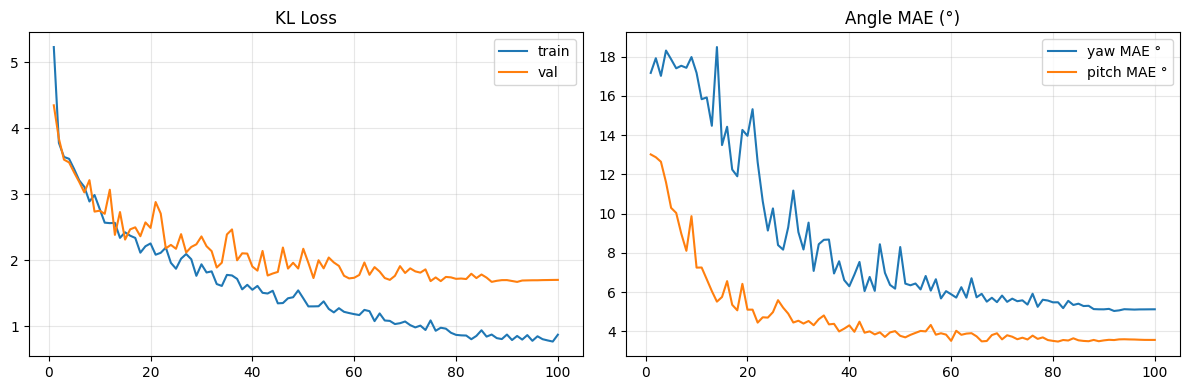

In [11]:
import matplotlib.pyplot as plt
fig,axes = plt.subplots(1,2,figsize=(12,4))
ep = range(1, len(history["train"])+1)
axes[0].plot(ep,history["train"],label="train"); axes[0].plot(ep,history["val"],label="val")
axes[0].set_title("KL Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep,history["yaw_mae"],label="yaw MAE °"); axes[1].plot(ep,history["pitch_mae"],label="pitch MAE °")
axes[1].set_title("Angle MAE (°)"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE,"training_curve.png"),dpi=120); plt.show()


## 9. Export ONNX — Merge backbone + new heads

In [12]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 19.2 MB/s eta 0:00:00


In [13]:
model.heads.load_state_dict(
    torch.load(os.path.join(CKPT_DIR, "best_heads.pt"), map_location="cpu"))
model.heads.eval().cpu()

HEADS_ONNX = "/content/heads.onnx"
dummy_feat = torch.zeros(1, FEAT_DIM)

# Export heads với opset 12
torch.onnx.export(
    model.heads,
    dummy_feat,
    HEADS_ONNX,
    input_names   = ["features"],
    output_names  = ["yaw", "pitch"],
    dynamic_axes  = {"features": {0: "batch"}},
    opset_version = 12,
    do_constant_folding = True,
)
print("Heads exported OK")

# Đọc 2 graph
backbone_model = onnx.load(BACKBONE_ONNX)
heads_model    = onnx.load(HEADS_ONNX)

bb_out_name   = backbone_model.graph.output[0].name
heads_in_name = heads_model.graph.input[0].name
print(f"Backbone output : '{bb_out_name}'")
print(f"Heads input     : '{heads_in_name}'")

# Rename input của heads → khớp với output backbone
# Đổi ở cả 3 chỗ: graph.input, node.input, value_info
for inp in heads_model.graph.input:
    if inp.name == heads_in_name:
        inp.name = bb_out_name

for node in heads_model.graph.node:
    for i, n in enumerate(node.input):
        if n == heads_in_name:
            node.input[i] = bb_out_name

for vi in heads_model.graph.value_info:
    if vi.name == heads_in_name:
        vi.name = bb_out_name

# Match IR version và opset
heads_model.ir_version = backbone_model.ir_version
heads_model.opset_import[0].version = backbone_model.opset_import[0].version
print(f"Opset: backbone={backbone_model.opset_import[0].version}  heads={heads_model.opset_import[0].version}")

# Merge
merged = onnx.compose.merge_models(
    backbone_model, heads_model,
    io_map=[(bb_out_name, bb_out_name)]
)

try:
    from onnxsim import simplify
    merged, ok = simplify(merged)
    if ok: print("Simplified OK")
except Exception as e:
    print(f"Simplify skip: {e}")

onnx.save(merged, OUTPUT_ONNX)
onnx.checker.check_model(merged)
print(f"\nSaved → {OUTPUT_ONNX}")

# Verify
sess     = ort.InferenceSession(OUTPUT_ONNX, providers=["CPUExecutionProvider"])
inp_name = sess.get_inputs()[0].name
out      = sess.run(None, {inp_name: np.zeros((1,3,448,448), dtype=np.float32)})
print(f"Input: {inp_name}  Output: yaw={out[0].shape}  pitch={out[1].shape}")
print("ONNX OK")

/tmp/ipykernel_1902/3714139864.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0611 02:02:08.134000 1902 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `GazeHeads([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GazeHeads([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Heads exported OK
Backbone output : '/Reshape_output_0'
Heads input     : 'features'
Opset: backbone=20  heads=20
Simplified OK

Saved → /content/drive/MyDrive/Colab Notebooks/PBL4/checkpoints/gaze_ft_100ep.onnx
Input: input  Output: yaw=(1, 90)  pitch=(1, 90)
ONNX OK


## 10. Verify

In [14]:
sess     = ort.InferenceSession(OUTPUT_ONNX, providers=["CPUExecutionProvider"])
inp_name = sess.get_inputs()[0].name

def decode_np(logits):
    e=np.exp(logits[0]-np.max(logits[0])); p=e/e.sum()
    return float(np.sum(p*np.arange(len(p)))*BIN_WIDTH-180)

from collections import defaultdict
per = defaultdict(lambda: {"yp":[],"yt":[]})
for _,row in val_df.iterrows():
    img=cv2.imread(os.path.join(IMG_DIR,row["image"]))
    if img is None: continue
    img=cv2.resize(img,(INPUT_SIZE,INPUT_SIZE))
    x=val_tf(Image.fromarray(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))).unsqueeze(0).numpy()
    out=sess.run(None,{inp_name:x})
    per[row["label"]]["yp"].append(decode_np(out[0]))
    per[row["label"]]["yt"].append(row["yaw_deg"])

print(f"{'Label':<8}  {'Pred yaw':>10}  {'Target':>8}  {'MAE':>6}")
print("-"*36)
for lb in ["left","center","right","up","down"]:
    if lb not in per: continue
    yp=np.mean(per[lb]["yp"]); yt=np.mean(per[lb]["yt"])
    mae=np.mean(np.abs(np.array(per[lb]["yp"])-np.array(per[lb]["yt"])))
    print(f"{lb:<8}  {yp:>+10.1f}°  {yt:>+7.1f}°  {mae:>5.1f}°")


Label       Pred yaw    Target     MAE
------------------------------------
left           -32.2°    -28.2°    5.2°
center          -2.2°     -0.6°    1.6°
right          +28.7°    +32.0°    6.0°
up              -1.5°     -1.1°    9.1°
down            +4.8°     +9.9°    6.1°
